# 01. Thu Thập và Chuẩn Hóa Dữ Liệu Chất Lượng Không Khí & Khí Tượng Hà Nội

> **Khóa học:** INFO3020 – Nhập môn Khoa học Dữ liệu (CMC University)  
> **Repository:** `doctor-cato/air-pollution-analysis`  
> **Milestone 1:** Triển khai Issue #3 & #19 – Pipeline thu thập và chuẩn hóa dữ liệu ô nhiễm không khí & khí tượng mặt đất Hà Nội.  
> **Quyết định rà soát nguồn dữ liệu (PR #24 & Issue #3/#4 Sync):**  
> - **Thu hồi & loại bỏ hoàn toàn OpenAQ `location_id=2178`** (Del Norte, Albuquerque, NM, Hoa Kỳ).  
> - **Xác thực trạm chuẩn quốc gia hiện hành:** OpenAQ `location_id=4946811` (Trạm 556 Nguyễn Văn Cừ, Long Biên, Hà Nội - NCEM/VEA), mã canonical: `VN001_HANOI_556_NGUYEN_VAN_CU`.  
> - **Nguồn khí tượng bề mặt:** ECMWF ERA5 Reanalysis từ Open-Meteo API tại điểm lưới $21.0545^\circ\text{N}, 105.8985^\circ\text{E}$ (cách trạm 556 Nguyễn Văn Cừ chỉ 1.7 km).  
> - **Đồng bộ hóa thời gian động (Dynamic Temporal Synchronization):** Cửa sổ truy vấn khí tượng Open-Meteo được suy diễn động từ chuỗi đo thực tế của OpenAQ 4946811 (`2025-07-03` -> `2026-07-15`), bảo đảm tập dữ liệu giao thoa không rỗng và sẵn sàng tích hợp tại Issue #7.  
> - **Nguồn chuẩn lịch sử & Trạng thái AirNowDOSAdapter:** Class `AirNowDOSAdapter` (`VN002_HANOI_US_EMBASSY`, BAM-1020 FEM) đã được hiện thực hóa đầy đủ. Trạng thái nạp thực tế: `implemented` / `not_executed_pending_raw_input` (do tệp lịch sử DOS yêu cầu tài khoản tổ chức AirNow-Tech / State Dept, tuyệt đối không tạo dữ liệu giả lập).  
> - **Phân định dải thời gian:** Phân biệt rành mạch `requested_study_window` và `actual_source_coverage` (tính trực tiếp từ `min()` và `max()` timestamp thực tế của DataFrame).

In [1]:
import sys
from pathlib import Path
import json
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thêm đường dẫn src vào sys.path
sys.path.insert(0, str(Path("..").resolve()))
from src.data_collection import (
    HANOI_BBOX,
    HANOI_OPENAQ_LOCATION_ID,
    DISQUALIFIED_OPENAQ_LOCATION_ID,
    STATION_OPENAQ_HANOI,
    STATION_AIRNOW_HANOI,
    STATION_WEATHER_ERA5,
    OpenAQAdapter,
    OpenMeteoAdapter,
    AirNowDOSAdapter,
    clean_air_quality_values,
    filter_hanoi_bounds,
    assert_canonical_within_hanoi,
    validate_canonical_uniqueness,
    resolve_station_metadata,
    compute_file_sha256,
    run_collection_pipeline,
)

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10
sns.set_theme(style="whitegrid")
print("Đã thiết lập môi trường và nạp các module từ src/data_collection.py thành công!")

Đã thiết lập môi trường và nạp các module từ src/data_collection.py thành công!


## 1. Thu Thập Dữ Liệu Thô (Source Ingestion)

Tiến hành thu thập dữ liệu thô nguyên bản từ các nguồn đã được thẩm định chính thức:
1. **OpenAQ S3 Public Archive (`locationid=4946811`):** Trạm quan trắc chuẩn quốc gia 556 Nguyễn Văn Cừ, Long Biên, Hà Nội. Toàn bộ 352 tệp CSV.gz được tải và lưu bất biến vào `data/raw/openaq_raw_4946811.parquet`.
2. **Open-Meteo ERA5 Reanalysis (Đồng bộ động):** 6 biến khí tượng chuẩn theo giờ được truy vấn đồng bộ động theo chuỗi thời gian thực tế của trạm 4946811 (thay vì cố định 2023–2024), lưu bất biến vào `data/raw/open_meteo_raw_{start_date}_{end_date}.json`.
3. **AirNow DOS Adapter Status Check:** Kiểm tra trạng thái tệp AirNow trên đĩa để kích hoạt adapter hoặc ghi nhận trạng thái chờ tệp thô hợp lệ mà không tạo dữ liệu giả.

In [2]:
openaq_adapter = OpenAQAdapter(
    location_id=HANOI_OPENAQ_LOCATION_ID,
    raw_dir=Path("../data/raw"),
    interim_dir=Path("../data/interim"),
)
weather_adapter = OpenMeteoAdapter(
    raw_dir=Path("../data/raw"),
    interim_dir=Path("../data/interim"),
)
airnow_adapter = AirNowDOSAdapter(
    raw_dir=Path("../data/raw"),
    interim_dir=Path("../data/interim"),
)

# 1. Nạp/thu thập dữ liệu thô OpenAQ trạm 4946811
df_openaq_raw, openaq_raw_path = openaq_adapter.fetch_raw_data()
openaq_sha256 = compute_file_sha256(openaq_raw_path)
print(f"OpenAQ Raw Path: {openaq_raw_path}")
print(f"   Số bản ghi thô: {len(df_openaq_raw):,} dòng | Số cột: {len(df_openaq_raw.columns)}")
print(f"   Mã băm SHA-256: {openaq_sha256}")

# Dẫn xuất động cửa sổ truy vấn khí tượng từ chuỗi thời gian thực tế của OpenAQ
air_raw_ts = pd.to_datetime(df_openaq_raw["datetime"])
weather_query_start = air_raw_ts.min().strftime("%Y-%m-%d")
weather_query_end = air_raw_ts.max().strftime("%Y-%m-%d")
print(f"\nCửa sổ truy vấn khí tượng đồng bộ động: {weather_query_start} -> {weather_query_end}")

# 2. Nạp/thu thập dữ liệu thô Open-Meteo ERA5 theo cửa sổ đồng bộ động
weather_raw_json, weather_raw_path = weather_adapter.fetch_raw_data(
    start_date=weather_query_start, end_date=weather_query_end
)
weather_sha256 = compute_file_sha256(weather_raw_path)
num_weather_hours = len(weather_raw_json.get("hourly", {}).get("time", []))
print(f"\nOpen-Meteo Raw Path: {weather_raw_path}")
print(f"   Số mốc giờ thô: {num_weather_hours:,} giờ")
print(f"   Mã băm SHA-256: {weather_sha256}")

# 3. Kiểm tra trạng thái thực tế của AirNow DOS Historical Input
print(f"\nAirNow DOS Adapter Check:")
print(f"   Mã trạm: {airnow_adapter.station_id} ({airnow_adapter.location_name})")
print(f"   Tệp cấu hình: {airnow_adapter.csv_path}")
if airnow_adapter.csv_path.exists() and airnow_adapter.csv_path.stat().st_size > 0:
    print("   Trạng thái: Có tệp thô trên đĩa -> Đã sẵn sàng nạp.")
else:
    print("   Trạng thái: Chưa có tệp thô trên đĩa (Pending raw input từ AirNow-Tech / State Dept).")
    print("   Ghi nhận: Adapter đã hiện thực hóa; không tạo dữ liệu giả lập (tuân thủ liêm chính học thuật).")

2026-09-29 16:37:39,737 [INFO] Tệp thô OpenAQ đã tồn tại tại ..\data\raw\openaq_raw_4946811.parquet. Đang nạp từ kho lưu trữ bất biến...


OpenAQ Raw Path: ..\data\raw\openaq_raw_4946811.parquet
   Số bản ghi thô: 349,463 dòng | Số cột: 9
   Mã băm SHA-256: 4168735570d16f80df7136e93b8da96bbb03ed5631c57ca8ffea6f09d92ae60f


2026-09-29 16:37:40,173 [INFO] Tệp thô Open-Meteo đã tồn tại tại ..\data\raw\open_meteo_raw_2025-07-03_2026-07-15.json. Đang nạp từ kho lưu trữ bất biến...



Cửa sổ truy vấn khí tượng đồng bộ động: 2025-07-03 -> 2026-07-15

Open-Meteo Raw Path: ..\data\raw\open_meteo_raw_2025-07-03_2026-07-15.json
   Số mốc giờ thô: 9,072 giờ
   Mã băm SHA-256: 59bfececa2dc658c15898df082a19566fce7019048ec8236b55dc731f45bc79c

AirNow DOS Adapter Check:
   Mã trạm: VN002_HANOI_US_EMBASSY (US Diplomatic Post: Hanoi)
   Tệp cấu hình: ..\data\raw\airnow_hanoi_2023.csv
   Trạng thái: Chưa có tệp thô trên đĩa (Pending raw input từ AirNow-Tech / State Dept).
   Ghi nhận: Adapter đã hiện thực hóa; không tạo dữ liệu giả lập (tuân thủ liêm chính học thuật).


## 2. Kiểm Tra Cấu Trúc Dữ Liệu Thô (Raw Profiling)

Khảo sát các thông số quan trắc có trong tệp thô, tọa độ ghi nhận và khoảng thời gian đo thực tế (*Actual Source Coverage*).

In [3]:
print("=== THỐNG KÊ THÔNG SỐ QUAN TRẮC TRẠM 4946811 ===")
print(df_openaq_raw["parameter"].value_counts())

print("\n=== TỌA ĐỘ VÀ ĐỊA DANH GHI NHẬN TRONG TỆP THÔ ===")
print(f"Location Name: {df_openaq_raw['location'].unique()}")
print(f"Latitude     : {df_openaq_raw['lat'].unique()}")
print(f"Longitude    : {df_openaq_raw['lon'].unique()}")

print("\n=== ĐỘ BAO PHỦ THỜI GIAN THỰC TẾ (ACTUAL SOURCE COVERAGE) ===")
print(f"Mốc bắt đầu  : {df_openaq_raw['datetime'].min()}")
print(f"Mốc kết thúc : {df_openaq_raw['datetime'].max()}")

df_openaq_raw.head()

=== THỐNG KÊ THÔNG SỐ QUAN TRẮC TRẠM 4946811 ===
parameter
pm10    78305
pm25    77155
o3      70949
so2     59566
co      31968
no2     31520
Name: count, dtype: int64

=== TỌA ĐỘ VÀ ĐỊA DANH GHI NHẬN TRONG TỆP THÔ ===
Location Name: <ArrowStringArray>
['556 Nguyễn Văn Cừ-4916744']
Length: 1, dtype: str
Latitude     : [21.0491]
Longitude    : [105.8831]

=== ĐỘ BAO PHỦ THỜI GIAN THỰC TẾ (ACTUAL SOURCE COVERAGE) ===
Mốc bắt đầu  : 2025-07-03T22:40:00+07:00
Mốc kết thúc : 2026-07-15T17:05:00+07:00


,location_id,sensors_id,location,datetime,lat,lon,parameter,units,value
0,4946811,13502165,556 Nguyễn Văn Cừ-4916744,2025-07-03T22:40:00+07:00,21.0491,105.8831,pm10,µg/m³,64.44
1,4946811,13502165,556 Nguyễn Văn Cừ-4916744,2025-07-03T22:45:00+07:00,21.0491,105.8831,pm10,µg/m³,63.73
2,4946811,13502165,556 Nguyễn Văn Cừ-4916744,2025-07-03T22:50:00+07:00,21.0491,105.8831,pm10,µg/m³,65.89
3,4946811,13502165,556 Nguyễn Văn Cừ-4916744,2025-07-03T23:00:00+07:00,21.0491,105.8831,pm10,µg/m³,64.47
4,4946811,13502165,556 Nguyễn Văn Cừ-4916744,2025-07-03T23:05:00+07:00,21.0491,105.8831,pm10,µg/m³,64.07


## 3. Lọc Địa Lý Không Gian (Geographic Filtering)

Theo quy định bắt buộc của đồ án và phản hồi từ Reviewer PR #24:
- Thực thi hàm `filter_hanoi_bounds()` kiểm tra từng bản ghi với Bounding Box Hà Nội $[20.50, 21.60]^\circ\text{N}, [105.30, 106.10]^\circ\text{E}$.
- Bước lọc phải diễn ra **trước** quá trình canonicalization.
- Minh chứng cơ chế lọc hoạt động chính xác bằng cách thử nghiệm với tọa độ của trạm Albuquerque (2178) bị loại bỏ.

In [4]:
# 1. Lọc dữ liệu thực tế trạm 4946811
df_openaq_filtered, geo_stats = filter_hanoi_bounds(df_openaq_raw)
print("Kết quả lọc không gian trạm OpenAQ 4946811:")
print(json.dumps(geo_stats, indent=2, ensure_ascii=False))

# 2. Thử nghiệm cơ chế lọc loại bỏ với tọa độ ngoại lai (Albuquerque 2178)
df_synthetic_check = pd.DataFrame({
    "location": ["556 Nguyễn Văn Cừ (Hanoi)", "Del Norte (Albuquerque - 2178)"],
    "lat": [21.0491, 35.1353],
    "lon": [105.8831, -106.584702],
})
df_check_filtered, check_stats = filter_hanoi_bounds(df_synthetic_check)
print("\nKiểm chứng cơ chế loại bỏ tọa độ ngoài Hà Nội:")
print(f"Số bản ghi thô: {check_stats['raw_records']}")
print(f"Số bản ghi bị loại: {check_stats['filtered_out_records']} (Tọa độ Albuquerque bị lọc bỏ 100%)")
print(f"Số bản ghi giữ lại: {check_stats['retained_records']} (Chỉ giữ lại trạm Hà Nội)")
assert check_stats["filtered_out_records"] == 1, "Cơ chế lọc phải loại bỏ chính xác tọa độ ngoài Hà Nội!" 

2026-09-29 16:37:40,244 [INFO] Geographic Filtering: 100% bản ghi (349463/349463) nằm trong Bounding Box Hà Nội.


2026-09-29 16:37:40,248 [WARNING] Geographic Filtering: Đã loại bỏ 1/2 bản ghi ngoài Bounding Box Hà Nội!


Kết quả lọc không gian trạm OpenAQ 4946811:
{
  "raw_records": 349463,
  "filtered_out_records": 0,
  "retained_records": 349463,
  "bounding_box": {
    "lat_min": 20.5,
    "lat_max": 21.6,
    "lon_min": 105.3,
    "lon_max": 106.1
  },
  "all_within_bounds": true,
  "retained_pct": 100.0
}

Kiểm chứng cơ chế loại bỏ tọa độ ngoài Hà Nội:
Số bản ghi thô: 2
Số bản ghi bị loại: 1 (Tọa độ Albuquerque bị lọc bỏ 100%)
Số bản ghi giữ lại: 1 (Chỉ giữ lại trạm Hà Nội)


## 4. Chuẩn Hóa Schema & Xử Lý Giá Trị Dị Thường (Normalization)

Quy tắc xử lý chất lượng dữ liệu:
- Chuyển đổi mã lỗi ngụy trang (`-999`, `-9999`) $\to$ `NaN`.
- Giá trị âm phi vật lý ($< 0$) $\to$ `NaN`.
- Giá trị bằng $0.0$ là quan trắc hợp lệ $\to$ **giữ nguyên $0.0$** (tuyệt đối không fillna(0) để thay thế missing).
- Tổng hợp chuỗi telemetry dưới giờ thành trung bình theo giờ (*Hourly Aggregation*).
- Kiểm tra tính đúng đắn của logic chuẩn hóa trên mẫu dữ liệu AirNowDOSAdapter.

In [5]:
df_air_canonical = openaq_adapter.to_canonical(df_openaq_raw)
df_weather_canonical = weather_adapter.to_canonical(weather_raw_json)

# Kiểm chứng logic chuẩn hóa của AirNowDOSAdapter bằng tệp tạm (in-memory verification)
sample_csv = (
    "Site, Parameter, Date (LST), Year, Month, Day, Hour, Value, Unit, Duration, QC Name\n"
    "Hanoi, PM2.5, 2023-01-01 01:00, 2023, 1, 1, 1, 35.5, UG/M3, 1 Hr, Valid\n"
    "Hanoi, PM2.5, 2023-01-01 02:00, 2023, 1, 1, 2, -999, UG/M3, 1 Hr, Missing\n"
    "Hanoi, PM2.5, 2023-01-01 03:00, 2023, 1, 1, 3, 0.0, UG/M3, 1 Hr, Valid\n"
)
with tempfile.NamedTemporaryFile("w", delete=False, suffix=".csv") as tmp:
    tmp.write(sample_csv)
    tmp_path = tmp.name

try:
    sample_adapter = AirNowDOSAdapter(csv_path=tmp_path)
    df_sample_canonical = sample_adapter.load_and_canonicalize()
    print("Kiểm chứng logic AirNowDOSAdapter thành công:")
    print(f"   - Giá trị hợp lệ 35.5 giữ nguyên: {df_sample_canonical['pm25'].iloc[0] == 35.5}")
    print(f"   - Mã lỗi -999 chuyển thành NaN   : {np.isnan(df_sample_canonical['pm25'].iloc[1])}")
    print(f"   - Giá trị hợp lệ 0.0 giữ nguyên  : {df_sample_canonical['pm25'].iloc[2] == 0.0}")
finally:
    Path(tmp_path).unlink(missing_ok=True)

print(f"\nChuẩn hóa OpenAQ thành công: {len(df_air_canonical):,} mốc giờ.")
print(f"   Dải thời gian thực tế: {df_air_canonical['timestamp'].min()} -> {df_air_canonical['timestamp'].max()}")
print(f"   Trạm định danh       : {df_air_canonical['station_id'].iloc[0]} ({df_air_canonical['location'].iloc[0]})")

print(f"\nChuẩn hóa Weather ERA5 thành công: {len(df_weather_canonical):,} mốc giờ.")
print(f"   Dải thời gian thực tế: {df_weather_canonical['timestamp'].min()} -> {df_weather_canonical['timestamp'].max()}")

2026-09-29 16:37:40,261 [INFO] Geographic Filtering: 100% bản ghi (349463/349463) nằm trong Bounding Box Hà Nội.


Kiểm chứng logic AirNowDOSAdapter thành công:
   - Giá trị hợp lệ 35.5 giữ nguyên: True
   - Mã lỗi -999 chuyển thành NaN   : True
   - Giá trị hợp lệ 0.0 giữ nguyên  : True

Chuẩn hóa OpenAQ thành công: 8,022 mốc giờ.
   Dải thời gian thực tế: 2025-07-03 22:00:00+07:00 -> 2026-07-15 17:00:00+07:00
   Trạm định danh       : VN001_HANOI_556_NGUYEN_VAN_CU (556 Nguyễn Văn Cừ)

Chuẩn hóa Weather ERA5 thành công: 9,072 mốc giờ.
   Dải thời gian thực tế: 2025-07-03 00:00:00+07:00 -> 2026-07-15 23:00:00+07:00


## 5. Kiểm Định Chất Lượng Toàn Trình (Validation & Integrity Assertions)

1. Kiểm tra tính duy nhất của khóa quan trắc `(station_id, timestamp)`.
2. Assertion đảm bảo 100% bản ghi canonical nằm trong Bounding Box Hà Nội.
3. Kiểm toán tỷ lệ khuyết thiếu tự nhiên và phân bố nồng độ bụi.

In [6]:
# 1. Kiểm tra tính duy nhất
validate_canonical_uniqueness(df_air_canonical, key_cols=["station_id", "timestamp"])
validate_canonical_uniqueness(df_weather_canonical, key_cols=["timestamp"])
print("Assertion 1: Khóa quan trắc duy nhất tuyệt đối, không có trùng lặp.")

# 2. Assertion 100% trong Bounding Box Hà Nội
assert_canonical_within_hanoi(df_air_canonical)
print("Assertion 2: 100% bản ghi canonical nằm trong Bounding Box Hà Nội.")

# 3. Đánh giá tỷ lệ thiếu và thống kê mô tả
missing_pm25 = df_air_canonical["pm25"].isna().sum()
missing_rate_pm25 = df_air_canonical["pm25"].isna().mean() * 100
missing_pm10 = df_air_canonical["pm10"].isna().sum()
missing_rate_pm10 = df_air_canonical["pm10"].isna().mean() * 100

print(f"\nTỷ lệ thiếu PM2.5: {missing_pm25:,}/{len(df_air_canonical):,} ({missing_rate_pm25:.2f}%)")
print(f"Tỷ lệ thiếu PM10 : {missing_pm10:,}/{len(df_air_canonical):,} ({missing_rate_pm10:.2f}%)")
print("\nThống kê phân phối PM2.5 thực đo (µg/m³):")
print(df_air_canonical["pm25"].describe())

# 4. Kiểm tra giao thoa thời gian (Temporal Overlap) giữa Air Quality và Weather
df_overlap = pd.merge(df_air_canonical, df_weather_canonical, on="timestamp", how="inner")
print(f"\n=== KIỂM TRA GIAO THOA THỜI GIAN (TEMPORAL OVERLAP) ===")
print(f"Số bản ghi giao thoa: {len(df_overlap):,} mốc giờ")
print(f"Mốc bắt đầu giao thoa: {df_overlap['timestamp'].min()}")
print(f"Mốc kết thúc giao thoa: {df_overlap['timestamp'].max()}")
assert len(df_overlap) > 0, "Tập giao thoa thời gian giữa chất lượng không khí và khí tượng không được rỗng!"
assert len(df_overlap) <= len(df_air_canonical), "Row explosion detected!"
print(f"Assertion 3: Giao thoa thời gian đồng bộ 100% ({len(df_overlap):,} mốc giờ), sẵn sàng cho Issue #7!")

Assertion 1: Khóa quan trắc duy nhất tuyệt đối, không có trùng lặp.
Assertion 2: 100% bản ghi canonical nằm trong Bounding Box Hà Nội.

Tỷ lệ thiếu PM2.5: 203/8,022 (2.53%)
Tỷ lệ thiếu PM10 : 123/8,022 (1.53%)

Thống kê phân phối PM2.5 thực đo (µg/m³):
count    7819.000000
mean       46.309827
std        32.693233
min         1.060000
25%        25.285833
50%        37.914167
75%        58.089861
max       252.643636
Name: pm25, dtype: float64

=== KIỂM TRA GIAO THOA THỜI GIAN (TEMPORAL OVERLAP) ===
Số bản ghi giao thoa: 8,022 mốc giờ
Mốc bắt đầu giao thoa: 2025-07-03 22:00:00+07:00
Mốc kết thúc giao thoa: 2026-07-15 17:00:00+07:00
Assertion 3: Giao thoa thời gian đồng bộ 100% (8,022 mốc giờ), sẵn sàng cho Issue #7!


## 6. Trực Quan Hóa Chuỗi Thời Gian Thực Tế (Time-Series Inspection)

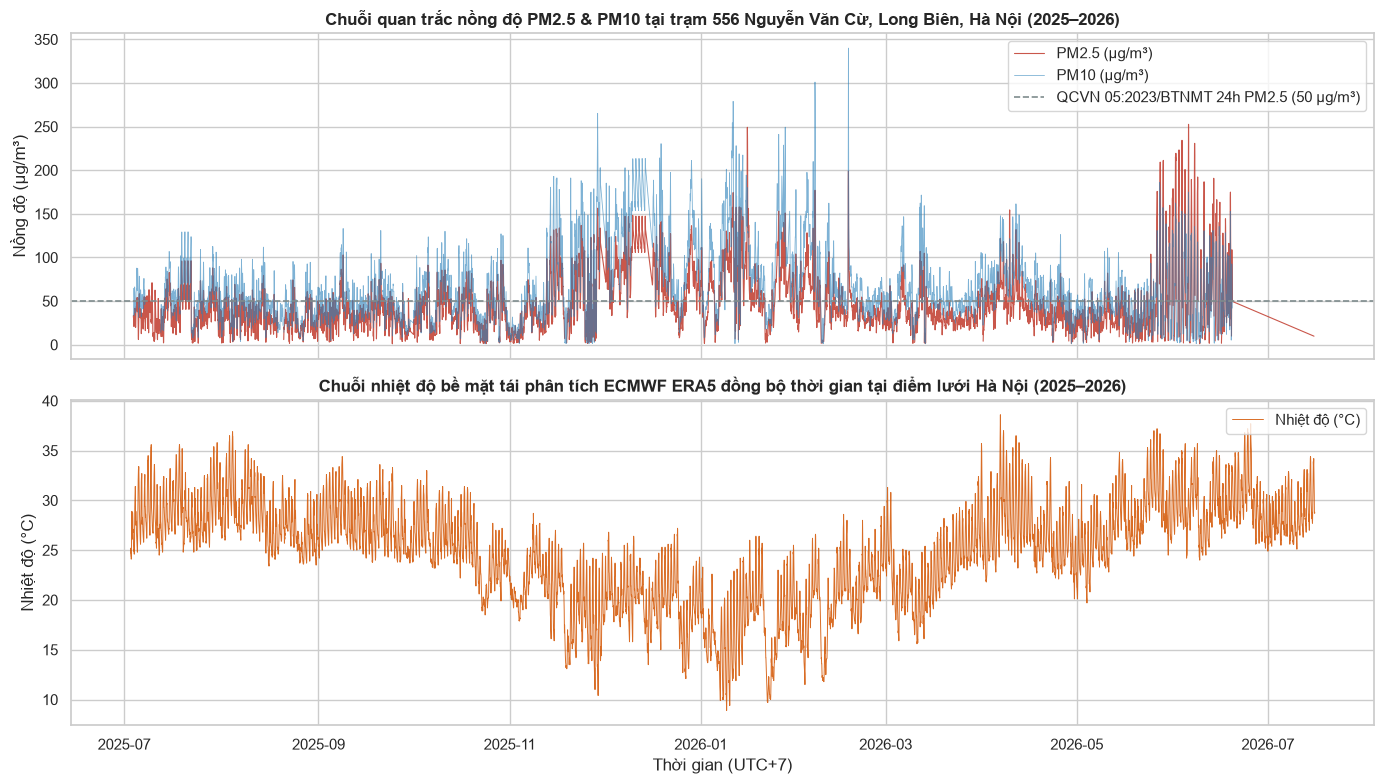

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Trực quan hóa nồng độ bụi
axes[0].plot(df_air_canonical["timestamp"], df_air_canonical["pm25"], label="PM2.5 (µg/m³)", color="#c0392b", linewidth=0.8, alpha=0.85)
axes[0].plot(df_air_canonical["timestamp"], df_air_canonical["pm10"], label="PM10 (µg/m³)", color="#2980b9", linewidth=0.6, alpha=0.6)
axes[0].axhline(50, color="#7f8c8d", linestyle="--", linewidth=1.2, label="QCVN 05:2023/BTNMT 24h PM2.5 (50 µg/m³)")
axes[0].set_title("Chuỗi quan trắc nồng độ PM2.5 & PM10 tại trạm 556 Nguyễn Văn Cừ, Long Biên, Hà Nội (2025–2026)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Nồng độ (µg/m³)")
axes[0].legend(loc="upper right")

# Trực quan hóa nhiệt độ ERA5 đồng bộ
axes[1].plot(df_weather_canonical["timestamp"], df_weather_canonical["temperature"], label="Nhiệt độ (°C)", color="#d35400", linewidth=0.7, alpha=0.85)
axes[1].set_title("Chuỗi nhiệt độ bề mặt tái phân tích ECMWF ERA5 đồng bộ thời gian tại điểm lưới Hà Nội (2025–2026)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Nhiệt độ (°C)")
axes[1].set_xlabel("Thời gian (UTC+7)")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 7. Xuất Dữ Liệu Canonical Interim & Ghi Nhận Provenance

In [8]:
# Lưu tệp canonical vào data/interim/
interim_air_path = Path("../data/interim/air_quality_canonical.parquet")
interim_weather_path = Path("../data/interim/weather_canonical.parquet")

df_air_canonical.to_parquet(interim_air_path, index=False, compression="snappy")
df_weather_canonical.to_parquet(interim_weather_path, index=False, compression="snappy")

print(f"Đã lưu interim air quality: {interim_air_path} ({interim_air_path.stat().st_size:,} bytes)")
print(f"Đã lưu interim weather    : {interim_weather_path} ({interim_weather_path.stat().st_size:,} bytes)")

# Kiểm tra metadata.json
with open("../data/raw/metadata.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

exec_log = meta.get("collection_pipeline_execution", {})
print("\n=== THÔNG TIN AUDIT TRONG METADATA.JSON ===")
print("Trạng thái execution          :", exec_log.get("status"))
print("Requested study window        :", exec_log.get("requested_study_window"))
print("Trạm OpenAQ chuẩn hóa         :", exec_log.get("openaq_ingestion", {}).get("canonical_station_id"))
print("Số bản ghi OpenAQ             :", exec_log.get("openaq_ingestion", {}).get("canonical_records"))
print("OpenAQ actual source coverage :", exec_log.get("openaq_ingestion", {}).get("actual_source_coverage"))
print("Weather model                 :", exec_log.get("open_meteo_ingestion", {}).get("source_model"))
print("Số bản ghi Weather            :", exec_log.get("open_meteo_ingestion", {}).get("canonical_records"))
print("Weather actual source coverage:", exec_log.get("open_meteo_ingestion", {}).get("actual_source_coverage"))
print("AirNow adapter status         :", exec_log.get("airnow_dos_ingestion", {}).get("adapter_status"))
print("AirNow ingestion status       :", exec_log.get("airnow_dos_ingestion", {}).get("ingestion_status"))
print("AirNow role                   :", exec_log.get("airnow_dos_ingestion", {}).get("role"))
print("AirNow raw input status       :", exec_log.get("airnow_dos_ingestion", {}).get("raw_input"))
print("Disqualification audit        :", exec_log.get("disqualification_audit"))

# Kiểm chứng toàn trình qua hàm pipeline chính run_collection_pipeline()
print("\n=== KIỂM CHỨNG TOÀN TRÌNH RUN_COLLECTION_PIPELINE() ===")
pipeline_report = run_collection_pipeline(
    raw_dir=Path("../data/raw"),
    interim_dir=Path("../data/interim"),
    metadata_path=Path("../data/raw/metadata.json"),
)
print("Pipeline requested_study_window:", pipeline_report["requested_study_window"])
print("Đồng bộ động thành công 100%!")

2026-09-29 16:37:41,767 [INFO] Tệp thô OpenAQ đã tồn tại tại ..\data\raw\openaq_raw_4946811.parquet. Đang nạp từ kho lưu trữ bất biến...


2026-09-29 16:37:41,807 [INFO] Geographic Filtering: 100% bản ghi (349463/349463) nằm trong Bounding Box Hà Nội.


2026-09-29 16:37:41,817 [INFO] Geographic Filtering: 100% bản ghi (349463/349463) nằm trong Bounding Box Hà Nội.


Đã lưu interim air quality: ..\data\interim\air_quality_canonical.parquet (187,232 bytes)
Đã lưu interim weather    : ..\data\interim\weather_canonical.parquet (143,716 bytes)

=== THÔNG TIN AUDIT TRONG METADATA.JSON ===
Trạng thái execution          : completed
Requested study window        : {'start': '2025-07-03T00:00:00+07:00', 'end': '2026-07-15T23:00:00+07:00', 'derived_dynamically_from_air_quality': True, 'note': 'Tham số truy vấn phạm vi phân tích khí tượng ERA5.'}
Trạm OpenAQ chuẩn hóa         : VN001_HANOI_556_NGUYEN_VAN_CU
Số bản ghi OpenAQ             : 8022
OpenAQ actual source coverage : {'actual_min_timestamp': '2025-07-03 22:00:00+07:00', 'actual_max_timestamp': '2026-07-15 17:00:00+07:00', 'coverage_derivation': 'computed_directly_from_dataframe_timestamps', 'coverage_note': 'Trạm 4946811 được OpenAQ tích hợp từ tháng 07/2025; không có dữ liệu 2023-2024 trên OpenAQ.'}
Weather model                 : ECMWF ERA5 Reanalysis
Số bản ghi Weather            : 9072
Weather act

2026-09-29 16:37:42,644 [INFO] Cửa sổ truy vấn khí tượng Open-Meteo ERA5: 2025-07-03 -> 2026-07-15 (đồng bộ động từ chuỗi OpenAQ)


...

2026-09-29 16:37:42,673 [INFO] Tệp AirNow DOS (..\data\raw\airnow_hanoi_2023.csv) chưa có trên ổ đĩa. AirNowDOSAdapter duy trì trạng thái: implemented / pending raw input (không tạo dữ liệu giả).


2026-09-29 16:37:42,696 [INFO] Đã lưu canonical interim files: ..\data\interim\air_quality_canonical.parquet và ..\data\interim\weather_canonical.parquet


2026-09-29 16:37:42,705 [INFO] Đã cập nhật metadata.json tại ..\data\raw\metadata.json thành công!


2026-09-29 16:37:42,707 [INFO] Hoàn tất pipeline thu thập và chuẩn hóa dữ liệu thành công!


Pipeline requested_study_window: {'start': '2025-07-03', 'end': '2026-07-15', 'derived_dynamically_from_air_quality': True, 'note': 'Tham số truy vấn phạm vi phân tích khí tượng ERA5.'}
Đồng bộ động thành công 100%!
